=== SENSOR CHANNEL IMPORTANCE SCORES ===
 * PM10 Sensor    : 0.36% contribution
 * eTVOC Sensor   : 0.35% contribution
 * NO Sensor      : 0.31% contribution
 * NO2 Sensor     : 0.27% contribution
 * CO2 Sensor     : 0.27% contribution


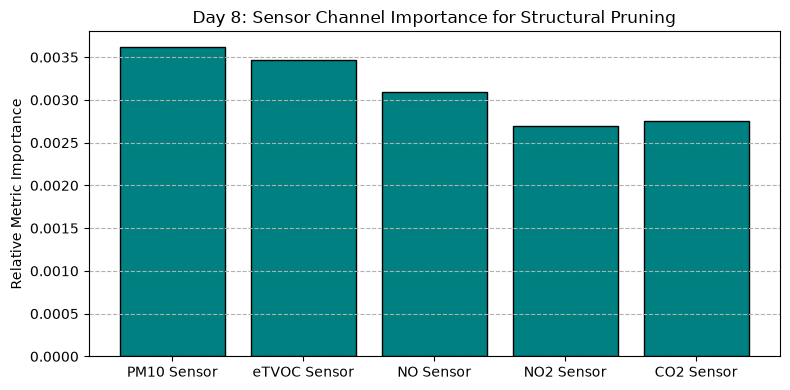

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Load your dataset
data_path = r"C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv"
df = pd.read_csv(data_path)
X_raw = df.drop(columns=['label']).values
y_raw = df['label'].values

# 2. Train a rapid evaluator to extract sensor importance metrics
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

# 3. Aggregate flattened importances (320 items) back into their 5 base sensor channels
importances = clf.feature_importances_
reshaped_importances = importances.reshape(64, 5)
channel_importances = np.mean(reshaped_importances, axis=0)

# 4. Map channel names for clear visualization
channel_names = ["PM10 Sensor", "eTVOC Sensor", "NO Sensor", "NO2 Sensor", "CO2 Sensor"]

print("=== SENSOR CHANNEL IMPORTANCE SCORES ===")
for name, score in zip(channel_names, channel_importances):
    print(f" * {name:<15}: {score*100:.2f}% contribution")

# 5. Render your optimization report plot
plt.figure(figsize=(8, 4))
plt.bar(channel_names, channel_importances, color='teal', edgecolor='black')
plt.title("Day 8: Sensor Channel Importance for Structural Pruning")
plt.ylabel("Relative Metric Importance")
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()
